In [1]:
import sys
sys.path.append("..")

from src.embedder import *
from src.data import load_dataset
from src.config import MODELS

import numpy as np
import umap
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

corpus, questions, categories = load_dataset()

In [2]:
best_model_name = MODELS[2]
texts = [record_to_text(rec) for rec in corpus]

embeddings = get_or_compute_embeddings(texts, best_model_name)

loading embedding from the cache...


In [3]:
reducer = umap.UMAP(n_neighbors=6, min_dist=0.2, random_state=42)
projection = reducer.fit_transform(embeddings)

df = pd.DataFrame({
    'x': projection[:, 0],
    'y': projection[:, 1],
    'name': [r['function_name'] for r in corpus],
    'description': [r['description'] for r in corpus],
    'language': [r['language'] for r in corpus],
    'category': [r['category'] for r in corpus]
})

df['category_label'] = df['category'].map(lambda k: categories.get(k, {}).get('label', 'Unknown'))
df['category_color'] = df['category'].map(lambda k: categories.get(k, {}).get('color', '#cccccc'))

C:\CPP\semantic-search-case\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


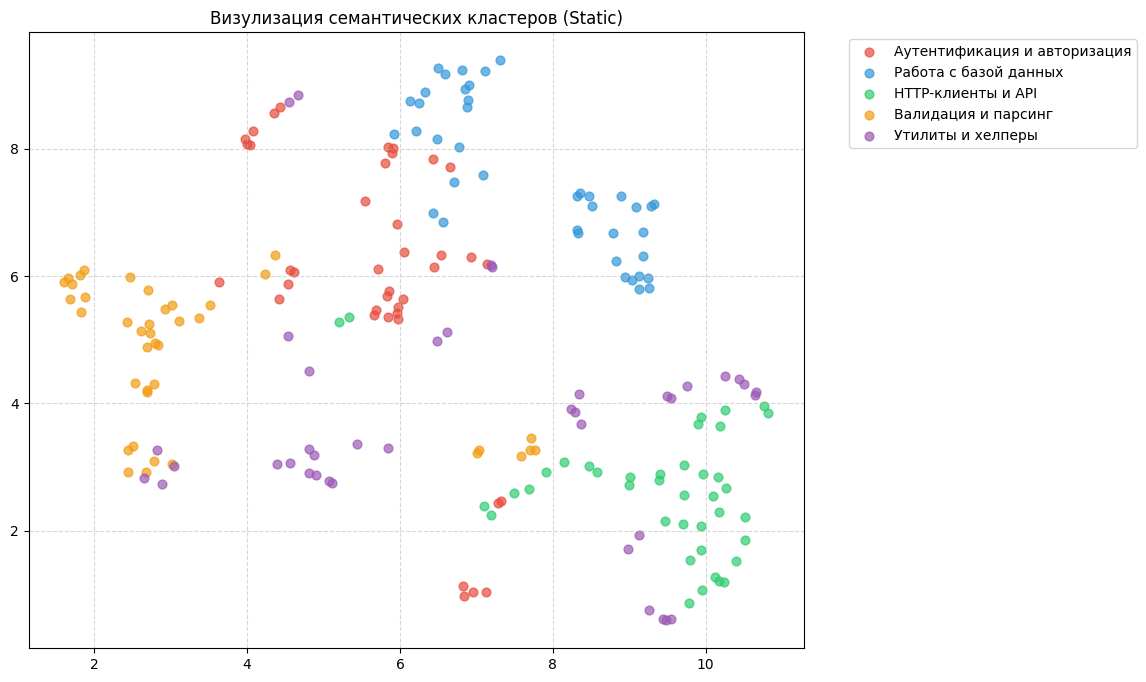

In [4]:
plt.figure(figsize=(10, 8))
for cat in df['category_label'].unique():
    mask = df['category_label'] == cat
    current_color = df.loc[mask, 'category_color'].iloc[0]
    plt.scatter(df.loc[mask, 'x'], df.loc[mask, 'y'], label=cat, color=current_color, s=40, alpha=0.7)

plt.title("Визулизация семантических кластеров (Static)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

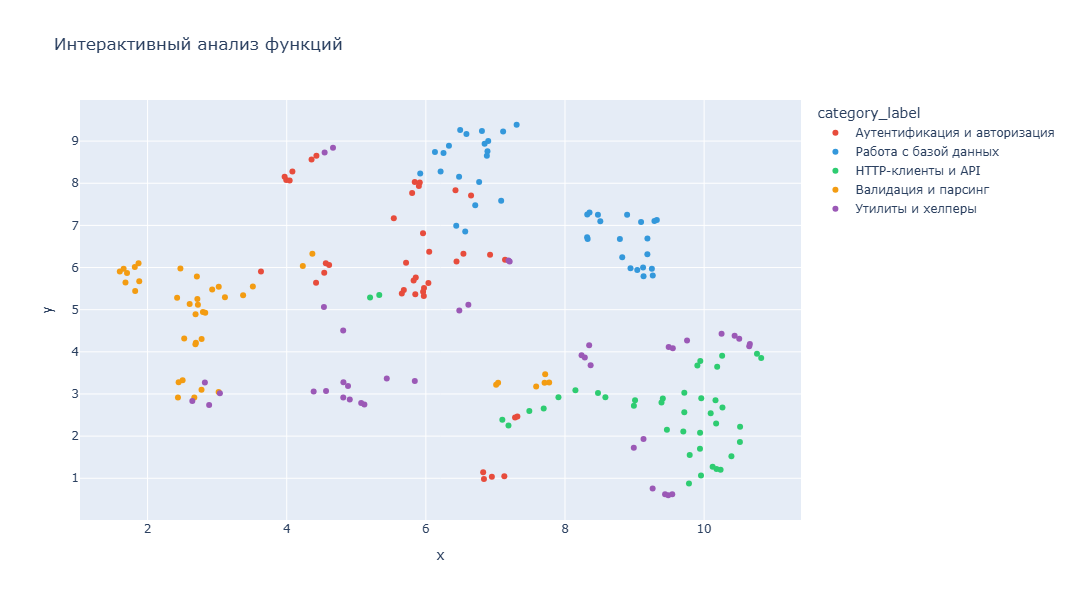

In [5]:
color_map = {
    row['label']: row['color']
    for row in categories.values()
}

fig = px.scatter(
    df, 
    x='x', 
    y='y', 
    color='category_label',
    color_discrete_map=color_map,
    width=800,
    height=600,
    hover_name='name', 
    hover_data=['description', 'language'], 
    title="Интерактивный анализ функций")
fig.show()